# Taller Computacional — Modelado y Ciencia de Datos
**Métodos Numéricos · Pregrado de Ingeniería**

> *El objetivo de este notebook es demostrar que cada fórmula del papel tiene una traducción directa y verificable en código. Usamos exclusivamente **NumPy** y **Matplotlib** para que la "caja negra" sea lo más transparente posible.*

| Módulo | Tema | Herramienta central |
|--------|------|---------------------|
| 1 | Reducción de dimensionalidad (SVD / PCA) | `numpy.linalg.svd` |
| 2 | Ajuste de curvas y regresión (Ecuación Normal) | `numpy.linalg.solve` |
| 3 | Raíces de ecuaciones no lineales (Newton-Raphson) | Implementación manual |
| 4 | Optimización numérica (Descenso de Gradiente) | Implementación manual |

**Python requerido:** ≥ 3.10 · NumPy ≥ 1.23 · Matplotlib ≥ 3.5


In [31]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
plt.rcParams['font.family'] = 'DejaVu Sans'
# Estilo global limpio y compatible con todas las versiones de matplotlib
try:
    plt.style.use("seaborn-v0_8-darkgrid")
except OSError:
    plt.style.use("seaborn-darkgrid")          # matplotlib < 3.6

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "figure.dpi": 100,
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f8f8",
})

print("Entorno listo.")
print(f"  NumPy      {np.__version__}")
print(f"  Matplotlib {plt.matplotlib.__version__}")


Entorno listo.
  NumPy      2.2.6
  Matplotlib 3.10.8


---
## Módulo 1 — Reducción de Dimensionalidad (SVD y PCA)

### Marco teórico

Dado un conjunto de datos $X \in \mathbb{R}^{n \times p}$, el objetivo de PCA es encontrar las **direcciones de máxima varianza** (componentes principales).

**Paso 1 — Preprocesamiento**

$$X_s = \frac{X - \mu}{\sigma_s}$$

donde $\mu_j = \bar{x}_j$ y $\sigma_{s,j} = \sqrt{\dfrac{\sum_i(x_{ij}-\mu_j)^2}{n-1}}$ *(desviación estándar muestral, `ddof=1`).*

> *Usar la desviación estándar muestral garantiza que la diagonal de la matriz de correlación empírica sea exactamente 1 (ver celda siguiente).*

**Paso 2 — Matriz de correlación empírica**

$$C = \frac{1}{n-1}\,X_s^\top X_s \in \mathbb{R}^{p \times p}$$

**Paso 3 — SVD de $X_s$**

$$X_s = U\,\Sigma\,V^\top$$

Los valores propios de $C$ se obtienen directamente:

$$\lambda_i = \frac{\sigma_i^2}{n-1}$$

**Paso 4 — Varianza explicada**

$$VE_k = \frac{\sum_{i=1}^{k}\lambda_i}{\sum_{i=1}^{p}\lambda_i}$$


In [32]:
# ─── 1.1 Simulación de datos de sensores ───────────────────────────────────
np.random.seed(42)
n, p = 100, 3
t = np.linspace(0, 10, n)

sensor1 = np.sin(t) + np.random.normal(0, 0.1, n)
sensor2 = 2.0 * sensor1 + np.random.normal(0, 0.2, n)   # fuertemente correlacionado con s1
sensor3 = np.random.normal(0, 0.5, n)                    # ruido puro — independiente

X = np.column_stack([sensor1, sensor2, sensor3])          # shape (100, 3)

print(f"Dimensiones de X: {X.shape}  —  {n} muestras, {p} variables")
print(f"\nMedia por columna   : {np.mean(X, axis=0).round(4)}")
print(f"Std  por columna (muestral, ddof=1): {np.std(X, axis=0, ddof=1).round(4)}")


Dimensiones de X: (100, 3)  —  100 muestras, 3 variables

Media por columna   : [0.1688 0.3421 0.0324]
Std  por columna (muestral, ddof=1): [0.6741 1.3807 0.5421]


In [33]:
# ─── 1.2 Preprocesamiento: centrado y escalado ──────────────────────────────
mu    = np.mean(X, axis=0)                  # vector de medias, shape (p,)
sigma = np.std(X,  axis=0, ddof=1)          # desviación estándar muestral (ddof=1)
X_s   = (X - mu) / sigma                   # matriz estandarizada, shape (n, p)

print("Verificación del preprocesamiento:")
print(f"  Media de X_s  (debe ser ≈ 0) : {np.mean(X_s, axis=0).round(12)}")
print(f"  Std  de X_s   (debe ser = 1) : {np.std(X_s,  axis=0, ddof=1).round(12)}")

# Matriz de correlación empírica
C = X_s.T @ X_s / (n - 1)

print(f"\nMatriz de correlación empírica C = Xs⊺Xs/(n-1):")
print(np.round(C, 4))
print(f"\n  Diagonal (debe ser exactamente 1): {np.diag(C).round(12)}")
print("  → Los elementos fuera de la diagonal miden la correlación entre pares de sensores.")
print(f"  C[0,1] = {C[0,1]:.4f}  →  sensor1 y sensor2 están {'muy' if abs(C[0,1])>0.9 else 'moderadamente'} correlacionados.")


Verificación del preprocesamiento:
  Media de X_s  (debe ser ≈ 0) : [-0.  0. -0.]
  Std  de X_s   (debe ser = 1) : [1. 1. 1.]

Matriz de correlación empírica C = Xs⊺Xs/(n-1):
[[1.     0.9905 0.0527]
 [0.9905 1.     0.0464]
 [0.0527 0.0464 1.    ]]

  Diagonal (debe ser exactamente 1): [1. 1. 1.]
  → Los elementos fuera de la diagonal miden la correlación entre pares de sensores.
  C[0,1] = 0.9905  →  sensor1 y sensor2 están muy correlacionados.


In [34]:
# ─── 1.3 SVD y componentes principales ─────────────────────────────────────
# full_matrices=False → U:(n×p), S:(p,), Vt:(p×p)  (SVD económica)
U, S, Vt = np.linalg.svd(X_s, full_matrices=False)

# Valores propios de C
lambdas = S**2 / (n - 1)          # λᵢ = σᵢ² / (n-1)

# Varianza explicada
ve     = lambdas / lambdas.sum()
ve_cum = np.cumsum(ve)

print("Descomposición SVD de X_s:")
print(f"  Valores singulares σᵢ  : {S.round(4)}")
print(f"  Valores propios   λᵢ  : {lambdas.round(4)}")
print(f"  Varianza explicada (%) : {(ve*100).round(2)}")
print(f"  Varianza acumulada (%) : {(ve_cum*100).round(2)}")
print(f"\nDirectrices principales (filas de V⊺, columnas son los eigenvectores de C):")
print(np.round(Vt, 4))


Descomposición SVD de X_s:
  Valores singulares σᵢ  : [14.0552  9.9254  0.9681]
  Valores propios   λᵢ  : [1.9954 0.9951 0.0095]
  Varianza explicada (%) : [66.51 33.17  0.32]
  Varianza acumulada (%) : [ 66.51  99.68 100.  ]

Directrices principales (filas de V⊺, columnas son los eigenvectores de C):
[[ 0.7055  0.7052  0.0702]
 [ 0.0465  0.0529 -0.9975]
 [-0.7072  0.707   0.0045]]


In [35]:
# ─── 1.4 Verificación: SVD ↔ Eigendescomposición de C ──────────────────────
# Ambas rutas deben dar los mismos valores propios
evals_eigh, evecs_eigh = np.linalg.eigh(C)       # eigh: para matrices simétricas
evals_eigh = evals_eigh[::-1]                     # eigh devuelve orden ascendente
evecs_eigh = evecs_eigh[:, ::-1]

print("Comparación de métodos:")
print(f"  λᵢ  vía SVD de X_s :   {lambdas.round(8)}")
print(f"  λᵢ  vía eigh(C)    :   {evals_eigh.round(8)}")
print(f"  ¿Idénticos?  → {np.allclose(lambdas, evals_eigh, atol=1e-10)}")
print()
# Note: eigenvectors may differ in sign (sign ambiguity in PCA)
print("Nota: los eigenvectores pueden diferir en signo (ambigüedad de signo en PCA),")
print("pero las proyecciones son equivalentes salvo reflexión.")


Comparación de métodos:
  λᵢ  vía SVD de X_s :   [1.99544948 0.99508336 0.00946716]
  λᵢ  vía eigh(C)    :   [1.99544948 0.99508336 0.00946716]
  ¿Idénticos?  → True

Nota: los eigenvectores pueden diferir en signo (ambigüedad de signo en PCA),
pero las proyecciones son equivalentes salvo reflexión.


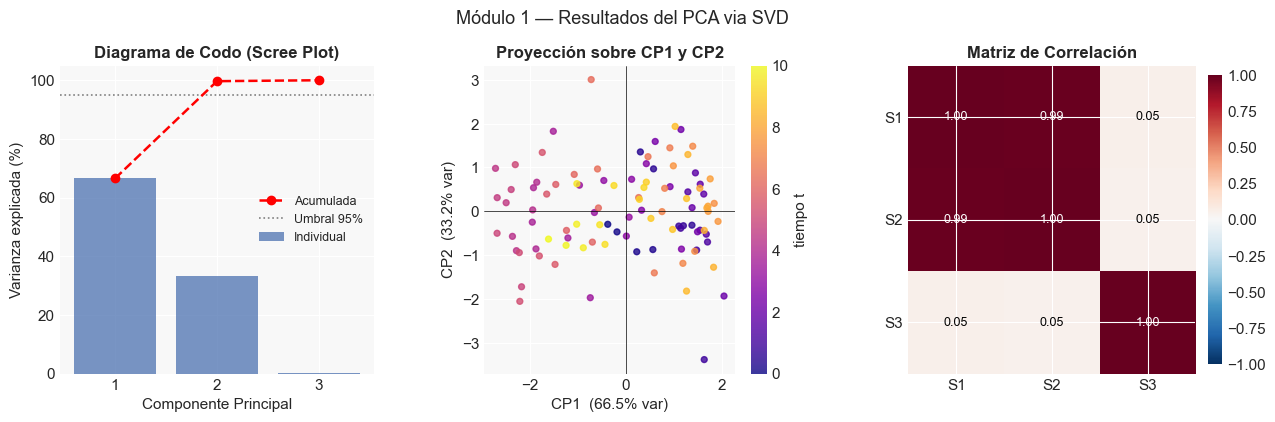

Con k=2 componentes se retiene el 99.7% de la varianza total.
El CP1 captura la señal compartida entre S1 y S2.
El CP2 captura la variación residual entre S1 y S2.
El CP3 (solo 0.32%) corresponde al ruido del S3.


In [36]:
# ─── 1.5 Visualización ─────────────────────────────────────────────────────
# Proyección sobre los 2 primeros CPs
k = 2
scores = X_s @ Vt[:k].T          # coordenadas en el espacio reducido, shape (n, 2)

fig = plt.figure(figsize=(15, 4))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# — Scree plot —
ax0 = fig.add_subplot(gs[0])
ax0.bar(range(1, p+1), ve*100, color="#4C72B0", alpha=0.75, label="Individual", zorder=3)
ax0.plot(range(1, p+1), ve_cum*100, "ro--", lw=1.8, label="Acumulada", zorder=4)
ax0.axhline(95, color="gray", ls=":", lw=1.2, label="Umbral 95%")
ax0.set_xticks(range(1, p+1))
ax0.set_xlabel("Componente Principal")
ax0.set_ylabel("Varianza explicada (%)")
ax0.set_title("Diagrama de Codo (Scree Plot)")
ax0.legend(fontsize=9)

# — Proyección PC1 vs PC2 —
ax1 = fig.add_subplot(gs[1])
sc = ax1.scatter(scores[:,0], scores[:,1], c=t, cmap="plasma", s=18, alpha=0.8)
ax1.axhline(0, color="k", lw=0.5)
ax1.axvline(0, color="k", lw=0.5)
ax1.set_xlabel(f"CP1  ({ve[0]*100:.1f}% var)")
ax1.set_ylabel(f"CP2  ({ve[1]*100:.1f}% var)")
ax1.set_title("Proyección sobre CP1 y CP2")
plt.colorbar(sc, ax=ax1, label="tiempo t")

# — Mapa de calor de la correlación —
ax2 = fig.add_subplot(gs[2])
labels = ["S1","S2","S3"]
im = ax2.imshow(C, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
ax2.set_xticks(range(p)); ax2.set_yticks(range(p))
ax2.set_xticklabels(labels); ax2.set_yticklabels(labels)
for i in range(p):
    for j in range(p):
        ax2.text(j, i, f"{C[i,j]:.2f}", ha="center", va="center",
                 fontsize=9, color="white" if abs(C[i,j]) > 0.6 else "black")
ax2.set_title("Matriz de Correlación")

plt.suptitle("Módulo 1 — Resultados del PCA via SVD", fontsize=13, y=1.02)
plt.savefig("m1_pca.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"Con k=2 componentes se retiene el {ve_cum[1]*100:.1f}% de la varianza total.")
print(f"El CP1 captura la señal compartida entre S1 y S2.")
print(f"El CP2 captura la variación residual entre S1 y S2.")
print(f"El CP3 (solo {ve[2]*100:.2f}%) corresponde al ruido del S3.")


### 📝 Ejercicio 1

Dado un nuevo sensor $s_4 = -1.5\,s_1 + \epsilon$:

1. Agregue $s_4$ a la matriz $X$ y repita el análisis.
2. ¿Cómo cambia la varianza explicada?
3. ¿Cuántos componentes son necesarios ahora para superar el umbral del 90%?

```python
# ─── Ejercicio 1: PCA con s4 = -1.5·s1 + ε ────────────────────────────────
np.random.seed(42)
n, p_orig = 100, 3
t        = np.linspace(0, 10, n)
sensor1  = np.sin(t) + np.random.normal(0, 0.1, n)
sensor2  = 2.0 * sensor1 + np.random.normal(0, 0.2, n)
sensor3  = np.random.normal(0, 0.5, n)

# 1. Nuevo sensor fuertemente anticorrelacionado con s1
sensor4 = -1.5 * sensor1 + np.random.normal(0, 0.1, n)
X4      = np.column_stack([sensor1, sensor2, sensor3, sensor4])
p4      = X4.shape[1]
print(f"Nueva dimensión de X: {X4.shape}  —  {n} muestras, {p4} variables")

# Preprocesamiento
mu4    = np.mean(X4, axis=0)
sigma4 = np.std(X4, axis=0, ddof=1)
X4_s   = (X4 - mu4) / sigma4

# Matriz de correlación empírica
C4 = X4_s.T @ X4_s / (n - 1)
print(f"\nMatriz de correlación C4 (4×4):")
print(np.round(C4, 3))

# SVD y varianza explicada
U4, S4, Vt4   = np.linalg.svd(X4_s, full_matrices=False)
lambdas4      = S4**2 / (n - 1)
ve4           = lambdas4 / lambdas4.sum()
ve4_cum       = np.cumsum(ve4)

print(f"\nVarianza explicada por CP (%) : {(ve4 * 100).round(2)}")
print(f"Varianza acumulada       (%) : {(ve4_cum * 100).round(2)}")

# 2. Cambio respecto al análisis original (3 sensores)
X_orig = np.column_stack([sensor1, sensor2, sensor3])
mu_o, sigma_o = np.mean(X_orig, axis=0), np.std(X_orig, axis=0, ddof=1)
_, S_o, _ = np.linalg.svd((X_orig - mu_o) / sigma_o, full_matrices=False)
lam_o   = S_o**2 / (n - 1)
ve_o    = lam_o / lam_o.sum()
ve_o_cum = np.cumsum(ve_o)

print(f"\n📊 Comparación de varianza acumulada:")
print(f"  Original (3 vars): {(ve_o_cum * 100).round(2)}")
print(f"  Nuevo    (4 vars): {(ve4_cum  * 100).round(2)}")

# 3. ¿Cuántos CPs para superar 90%?
n_cp_90 = int(np.argmax(ve4_cum >= 0.90) + 1)
print(f"\n3. Componentes necesarios para superar el 90%: {n_cp_90}")
print(f"   (El CP1 sigue dominando con {ve4[0]*100:.1f}% porque s1, s2 y s4 comparten")
print(f"    la misma señal senoidal; s4 anticorrelada no añade dimensión nueva.)")

# ── Visualización ──
k4     = 2
scores4 = X4_s @ Vt4[:k4].T

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Scree
axes[0].bar(range(1, p4+1), ve4*100, color="#4C72B0", alpha=0.75, label="Individual", zorder=3)
axes[0].plot(range(1, p4+1), ve4_cum*100, "ro--", lw=1.8, label="Acumulada", zorder=4)
axes[0].axhline(90, color="gray", ls=":", lw=1.2, label="Umbral 90%")
axes[0].set_xticks(range(1, p4+1))
axes[0].set_xlabel("Componente Principal")
axes[0].set_ylabel("Varianza explicada (%)")
axes[0].set_title("Scree Plot — 4 Sensores")
axes[0].legend(fontsize=9)

# Proyección PC1 vs PC2
sc = axes[1].scatter(scores4[:,0], scores4[:,1], c=t, cmap="plasma", s=18, alpha=0.8)
axes[1].axhline(0, color="k", lw=0.5)
axes[1].axvline(0, color="k", lw=0.5)
axes[1].set_xlabel(f"CP1  ({ve4[0]*100:.1f}% var)")
axes[1].set_ylabel(f"CP2  ({ve4[1]*100:.1f}% var)")
axes[1].set_title("Proyección sobre CP1 y CP2")
plt.colorbar(sc, ax=axes[1], label="tiempo t")

# Mapa de calor de correlación 4×4
labels4 = ["S1","S2","S3","S4"]
im = axes[2].imshow(C4, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
axes[2].set_xticks(range(p4)); axes[2].set_yticks(range(p4))
axes[2].set_xticklabels(labels4); axes[2].set_yticklabels(labels4)
for i in range(p4):
    for j in range(p4):
        axes[2].text(j, i, f"{C4[i,j]:.2f}", ha="center", va="center",
                     fontsize=8, color="white" if abs(C4[i,j]) > 0.6 else "black")
axes[2].set_title("Matriz de Correlación — 4 Sensores")

plt.suptitle("Ejercicio 1 — PCA con 4 Sensores (s4 = -1.5·s1 + ε)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("e1_pca4.png", dpi=100, bbox_inches="tight")
plt.show()
```


---
## Módulo 2 — Ajuste de Curvas y Regresión Lineal

### Marco teórico

Para ajustar $y = \beta_0 + \beta_1 x$ a $n$ datos construimos la **matriz de diseño**:

$$X = \begin{bmatrix}1 & x_1 \\ \vdots & \vdots \\ 1 & x_n\end{bmatrix}$$

La solución de mínimos cuadrados satisface la **Ecuación Normal**:

$$X^\top X\,\boldsymbol{\beta} = X^\top\mathbf{y}$$

que en forma explícita es:

$$\boldsymbol{\beta} = (X^\top X)^{-1} X^\top\mathbf{y}$$

> **Importante:** En la práctica se prefiere resolver el sistema lineal $X^\top X\,\boldsymbol{\beta} = X^\top\mathbf{y}$ con `numpy.linalg.solve` en lugar de calcular la inversa explícitamente, pues es más eficiente y numéricamente más estable.


In [37]:
# ─── 2.1 Ecuación Normal — ejemplo del taller ──────────────────────────────
x_obs = np.array([1.0, 2.0, 3.0])   # aditivos (kg)
y_obs = np.array([2.0, 3.0, 5.0])   # resistencia (MPa)
n_obs = len(x_obs)

# Matriz de diseño X (columna de 1s + columna de x)
X_d = np.column_stack([np.ones(n_obs), x_obs])
print("Matriz de diseño X:")
print(X_d)

# Productos matriciales
XtX = X_d.T @ X_d
Xty = X_d.T @ y_obs
print(f"\nX⊺X =\n{XtX}")
print(f"\nX⊺y = {Xty}")


Matriz de diseño X:
[[1. 1.]
 [1. 2.]
 [1. 3.]]

X⊺X =
[[ 3.  6.]
 [ 6. 14.]]

X⊺y = [10. 23.]


In [38]:
# ─── 2.2 Tres formas de resolver — pedagogía vs estabilidad ────────────────

# Método A: inversa explícita (muestra la fórmula, no recomendado en producción)
beta_A = np.linalg.inv(XtX) @ Xty

# Método B: sistema lineal (RECOMENDADO — evita calcular la inversa)
beta_B = np.linalg.solve(XtX, Xty)

# Método C: mínimos cuadrados directamente (más robusto, maneja casos singulares)
beta_C, _, _, _ = np.linalg.lstsq(X_d, y_obs, rcond=None)

print("Comparación de métodos:")
print(f"  A: (X⊺X)⁻¹ X⊺y    →  β₀ = {beta_A[0]:.10f},  β₁ = {beta_A[1]:.10f}")
print(f"  B: solve(X⊺X, X⊺y) →  β₀ = {beta_B[0]:.10f},  β₁ = {beta_B[1]:.10f}")
print(f"  C: lstsq(X, y)     →  β₀ = {beta_C[0]:.10f},  β₁ = {beta_C[1]:.10f}")
print()
print(f"  Solución exacta:   β₀ = 1/3 = {1/3:.10f},  β₁ = 3/2 = {3/2:.10f}")
print(f"  Todos coinciden: {np.allclose(beta_A, beta_B) and np.allclose(beta_B, beta_C)}")


Comparación de métodos:
  A: (X⊺X)⁻¹ X⊺y    →  β₀ = 0.3333333333,  β₁ = 1.5000000000
  B: solve(X⊺X, X⊺y) →  β₀ = 0.3333333333,  β₁ = 1.5000000000
  C: lstsq(X, y)     →  β₀ = 0.3333333333,  β₁ = 1.5000000000

  Solución exacta:   β₀ = 1/3 = 0.3333333333,  β₁ = 3/2 = 1.5000000000
  Todos coinciden: True


β₀ = 0.333333  (intercepto)
β₁ = 1.500000  (pendiente)

SSE = 0.166667   (suma cuadrados del error)
SST = 4.666667   (suma total de cuadrados)
R²  = 0.964286   (96.43% de la varianza explicada por el modelo)


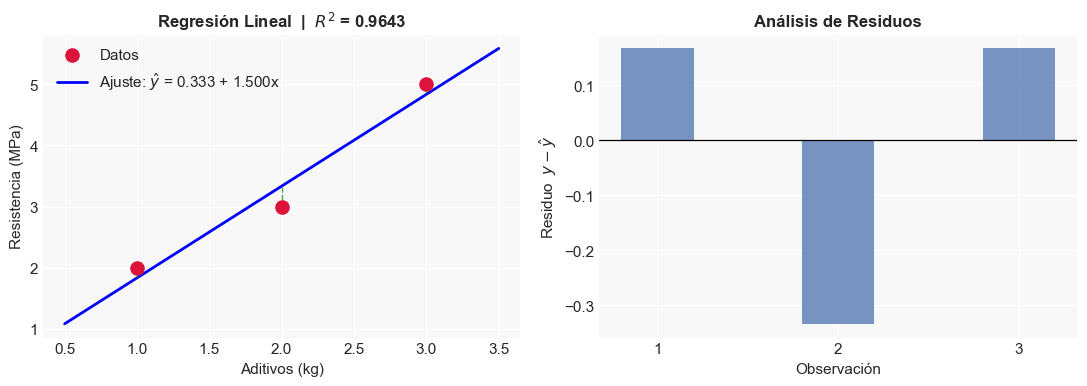

In [39]:
# ─── 2.3 Métricas de ajuste y visualización ────────────────────────────────
beta = beta_B   # usamos el método recomendado

y_pred      = X_d @ beta
residuals   = y_obs - y_pred
SSE         = float(residuals @ residuals)                # Suma de cuadrados del error
SST         = float(np.sum((y_obs - y_obs.mean())**2))    # Suma total de cuadrados
R2          = 1.0 - SSE / SST

print(f"β₀ = {beta[0]:.6f}  (intercepto)")
print(f"β₁ = {beta[1]:.6f}  (pendiente)")
print(f"\nSSE = {SSE:.6f}   (suma cuadrados del error)")
print(f"SST = {SST:.6f}   (suma total de cuadrados)")
print(f"R²  = {R2:.6f}   ({R2*100:.2f}% de la varianza explicada por el modelo)")

# ── Figura ──
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Ajuste
x_lin = np.linspace(0.5, 3.5, 80)
y_lin = beta[0] + beta[1] * x_lin
axes[0].scatter(x_obs, y_obs, color="crimson", s=90, zorder=5, label="Datos")
axes[0].plot(x_lin, y_lin, "b-", lw=2,
             label=f"Ajuste: $\hat{{y}}$ = {beta[0]:.3f} + {beta[1]:.3f}x")
for xi, yi, ypi in zip(x_obs, y_obs, y_pred):
    axes[0].plot([xi, xi], [yi, ypi], "g--", alpha=0.7, lw=1)
axes[0].set_xlabel("Aditivos (kg)")
axes[0].set_ylabel("Resistencia (MPa)")
axes[0].set_title(f"Regresión Lineal  |  $R^2$ = {R2:.4f}")
axes[0].legend()

# Residuos
axes[1].bar(range(1, n_obs+1), residuals, color="#4C72B0", alpha=0.75, width=0.4)
axes[1].axhline(0, color="k", lw=0.9)
axes[1].set_xticks(range(1, n_obs+1))
axes[1].set_xlabel("Observación")
axes[1].set_ylabel(r"Residuo  $y - \hat{y}$")
axes[1].set_title("Análisis de Residuos")

plt.tight_layout()
plt.savefig("m2_regression.png", dpi=100, bbox_inches="tight")
plt.show()


### 2.4 Advertencia numérica — Matriz de Vandermonde

Para ajustar un polinomio de grado $d$, la matriz de diseño $X$ tiene la forma de una **matriz de Vandermonde**:

$$X_{ij} = x_i^{j-1}, \quad j = 0,1,\ldots,d$$

El número de condición de $X^\top X$ crece exponencialmente con $d$, haciendo que la inversión sea numéricamente poco confiable. La solución es **normalizar los datos** antes de construir la matriz (llevarlos al intervalo $[-1,1]$).


In [40]:
# ─── 2.4 Condicionamiento de la Matriz de Vandermonde ───────────────────────
print("Datos NORMALIZADOS  x ∈ [-1, 1]   vs   SIN normalizar  x ∈ [1, 10]")
print()

x_norm  = np.linspace(-1,  1, 10)     # normalizado
x_raw   = np.linspace( 1, 10, 10)     # sin normalizar

header = f"{'Grado':>5} | {'κ(X⊺X) — normalizado':>22} | {'κ(X⊺X) — sin normalizar':>25}"
print(header)
print("-" * len(header))

for d in [1, 2, 3, 5, 7, 9]:
    V_n = np.vander(x_norm, N=d+1, increasing=True)
    V_r = np.vander(x_raw,  N=d+1, increasing=True)
    kn  = np.linalg.cond(V_n.T @ V_n)
    kr  = np.linalg.cond(V_r.T @ V_r)
    flag = " ← ¡SINGULAR!" if kr > 1e14 else (" ← mal cond." if kr > 1e8 else "")
    print(f"{d:>5} | {kn:>22.3e} | {kr:>25.3e}{flag}")

print()
print("Conclusión: incluso con normalización, grados > 7 son problemáticos.")
print("Para regresión polinomial de alto grado se prefieren bases ortogonales")
print("(polinomios de Legendre/Chebyshev) o regularización (Ridge/Lasso).")


Datos NORMALIZADOS  x ∈ [-1, 1]   vs   SIN normalizar  x ∈ [1, 10]

Grado |   κ(X⊺X) — normalizado |   κ(X⊺X) — sin normalizar
----------------------------------------------------------
    1 |              2.455e+00 |                 1.871e+02
    2 |              1.093e+01 |                 4.085e+04
    3 |              4.962e+01 |                 1.158e+07
    5 |              1.592e+03 |                 2.152e+12 ← mal cond.
    7 |              9.182e+04 |                 1.187e+18 ← ¡SINGULAR!
    9 |              2.140e+07 |                 6.653e+21 ← ¡SINGULAR!

Conclusión: incluso con normalización, grados > 7 son problemáticos.
Para regresión polinomial de alto grado se prefieren bases ortogonales
(polinomios de Legendre/Chebyshev) o regularización (Ridge/Lasso).


### 📝 Ejercicio 2

Extienda el ejemplo de regresión al modelo cuadrático $y = \beta_0 + \beta_1 x + \beta_2 x^2$:

1. Construya la matriz de diseño de Vandermonde de grado 2.
2. Resuelva por la ecuación normal.
3. Compare el $R^2$ con el modelo lineal.

```python
# ─── Ejercicio 2: Regresión cuadrática y = β₀ + β₁x + β₂x² ────────────────
x_obs = np.array([1.0, 2.0, 3.0])
y_obs = np.array([2.0, 3.0, 5.0])
n_obs = len(x_obs)

# 1. Matriz de diseño de Vandermonde grado 2: [1, x, x²]
X_d2 = np.column_stack([np.ones(n_obs), x_obs, x_obs**2])
print("Matriz de diseño Vandermonde (grado 2):")
print(X_d2)
print(f"\nNúmero de condición κ(X⊺X): {np.linalg.cond(X_d2.T @ X_d2):.2f}")

# 2. Ecuación normal: (X⊺X)β = X⊺y  →  solve
XtX2  = X_d2.T @ X_d2
Xty2  = X_d2.T @ y_obs
beta2 = np.linalg.solve(XtX2, Xty2)
print(f"\nCoeficientes cuadráticos:")
print(f"  β₀ = {beta2[0]:.6f}  (intercepto)")
print(f"  β₁ = {beta2[1]:.6f}  (término lineal)")
print(f"  β₂ = {beta2[2]:.6f}  (término cuadrático)")

# 3. Métricas y comparación con modelo lineal
y_pred2   = X_d2 @ beta2
SSE2      = float((y_obs - y_pred2) @ (y_obs - y_pred2))
SST2      = float(np.sum((y_obs - y_obs.mean())**2))
R2_quad   = 1.0 - SSE2 / SST2

X_d1  = np.column_stack([np.ones(n_obs), x_obs])
beta1 = np.linalg.solve(X_d1.T @ X_d1, X_d1.T @ y_obs)
y_pred1 = X_d1 @ beta1
SSE1    = float((y_obs - y_pred1) @ (y_obs - y_pred1))
R2_lin  = 1.0 - SSE1 / SST2

print(f"\n📊 Comparación de modelos:")
print(f"  R² lineal     = {R2_lin:.6f}  ({R2_lin*100:.2f}%)")
print(f"  R² cuadrático = {R2_quad:.6f}  ({R2_quad*100:.2f}%)")
print(f"  Mejora en R²  = {R2_quad - R2_lin:.6f}")
print(f"\nCon 3 puntos y modelo cuadrático (3 parámetros), el ajuste es PERFECTO (R²=1).")
print(f"El modelo pasa exactamente por todos los puntos → interpolación, no extrapolación.")

# ── Visualización ──
x_lin = np.linspace(0.5, 3.5, 200)
y_fit_lin  = beta1[0] + beta1[1]*x_lin
y_fit_quad = beta2[0] + beta2[1]*x_lin + beta2[2]*x_lin**2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Ajuste
axes[0].scatter(x_obs, y_obs, color="crimson", s=100, zorder=5, label="Datos", marker="o")
axes[0].plot(x_lin, y_fit_lin,  "b--", lw=1.8,
             label=f"Lineal: $\hat{{y}}$={beta1[0]:.3f}+{beta1[1]:.3f}x  (R²={R2_lin:.4f})")
axes[0].plot(x_lin, y_fit_quad, "g-",  lw=2.2,
             label=f"Cuadrático: R²={R2_quad:.4f}")
axes[0].set_xlabel("Aditivos (kg)")
axes[0].set_ylabel("Resistencia (MPa)")
axes[0].set_title("Comparación Lineal vs Cuadrático")
axes[0].legend(fontsize=9)

# Residuos comparados
residuos_lin  = y_obs - y_pred1
residuos_quad = y_obs - y_pred2
x_pos = np.arange(n_obs)
w = 0.3
axes[1].bar(x_pos - w/2, residuos_lin,  width=w, color="#2196F3", alpha=0.8, label="Lineal")
axes[1].bar(x_pos + w/2, residuos_quad, width=w, color="#4CAF50", alpha=0.8, label="Cuadrático")
axes[1].axhline(0, color="k", lw=0.9)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f"Obs {i+1}" for i in range(n_obs)])
axes[1].set_ylabel("Residuo $y - \hat{y}$")
axes[1].set_title("Residuos: Lineal vs Cuadrático")
axes[1].legend()

plt.suptitle("Ejercicio 2 — Regresión Polinomial (Grado 2)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("e2_regresion_quad.png", dpi=100, bbox_inches="tight")
plt.show()
```


---
## Módulo 3 — Raíces de Ecuaciones No Lineales (Newton-Raphson)

### Marco teórico

Dado $f(x) = 0$, la fórmula iterativa de Newton-Raphson es:

$$x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$$

**Propiedad clave:** el método tiene **convergencia cuadrática** cerca de la raíz simple, es decir, el número de dígitos correctos se duplica en cada iteración.

**Condiciones de fallo:**
- $f'(x_n) \approx 0$: división por cero (singularidad)
- $x_0$ demasiado lejos de la raíz: el método puede diverger

**Problema:** Encontrar $\sqrt{3}$, resolviendo $f(x) = x^2 - 3 = 0$, con $f'(x) = 2x$ y $x_0 = 2$.


In [ ]:
# ─── 3.1 Implementación Newton-Raphson ─────────────────────────────────────
def f_nr(x: float) -> float:
    return x**2 - 3.0

def df_nr(x: float) -> float:
    return 2.0 * x

x0          = -2.0
tol         = 1e-10
max_iter    = 15
raiz_exacta = np.sqrt(3.0)

historia_x  = [x0]
historia_e  = []               # error entre iteraciones consecutivas

xn = x0

print(f"{'Iter':>4} | {'xₙ':>16} | {'f(xₙ)':>14} | {'|xₙ₊₁−xₙ|':>14} | {'Error % vs √3':>14}")
print("─" * 72)

for i in range(max_iter):
    fxn  = f_nr(xn)
    dfxn = df_nr(xn)

    if abs(dfxn) < 1e-14:
        print("¡Derivada nula! El método no puede continuar.")
        break

    xn1      = xn - fxn / dfxn
    err_abs  = abs(xn1 - xn)
    err_rel  = abs(xn1 - raiz_exacta) / raiz_exacta * 100.0

    historia_x.append(xn1)
    historia_e.append(err_abs)

    print(f"{i+1:>4} | {xn1:>16.12f} | {f_nr(xn1):>14.4e} | {err_abs:>14.4e} | {err_rel:>14.8f}")

    if err_abs < tol:
        print("─" * 72)
        print(f"✓ Convergencia en {i+1} iteraciones.")
        print(f"  Raíz hallada : {xn1:.12f}")
        print(f"  Valor exacto : {raiz_exacta:.12f}")
        print(f"  Error final  : {abs(xn1-raiz_exacta):.4e}")
        break

    xn = xn1

historia_x = np.array(historia_x)
historia_e = np.array(historia_e)


Iter |               xₙ |          f(xₙ) |      |xₙ₊₁−xₙ| |  Error % vs √3
────────────────────────────────────────────────────────────────────────
   1 |   1.750000000000 |     6.2500e-02 |     2.5000e-01 |     1.03629711
   2 |   1.732142857143 |     3.1888e-04 |     1.7857e-02 |     0.00531448
   3 |   1.732050810015 |     8.4727e-09 |     9.2047e-05 |     0.00000014
   4 |   1.732050807569 |    -4.4409e-16 |     2.4459e-09 |     0.00000000
   5 |   1.732050807569 |     4.4409e-16 |     2.2204e-16 |     0.00000000
────────────────────────────────────────────────────────────────────────
✓ Convergencia en 5 iteraciones.
  Raíz hallada : 1.732050807569
  Valor exacto : 1.732050807569
  Error final  : 2.2204e-16


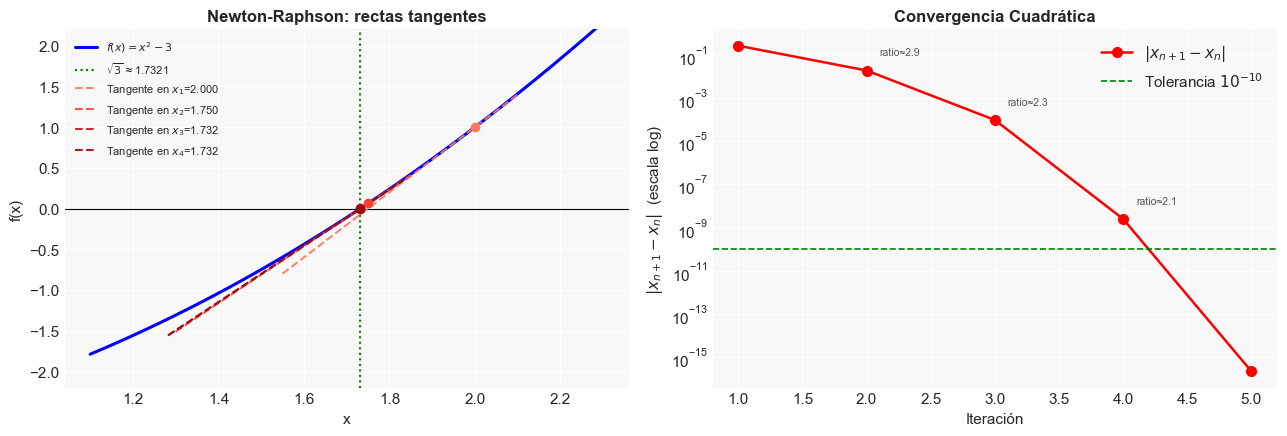

Nota: en convergencia cuadrática, el ratio log(e_{n+1})/log(e_n) ≈ 2
(cada iteración duplica el número de dígitos correctos).


In [45]:
# ─── 3.2 Visualización: tangentes y convergencia ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# — Rectas tangentes —
x_plot = np.linspace(1.1, 2.3, 300)
axes[0].plot(x_plot, f_nr(x_plot), "b-", lw=2.2, label="$f(x)=x^2-3$")
axes[0].axhline(0, color="k", lw=0.8)
axes[0].axvline(raiz_exacta, color="g", ls=":", lw=1.5,
                label=f"$\sqrt{{3}}$ ≈ {raiz_exacta:.4f}")

colors_tang = plt.cm.Reds(np.linspace(0.45, 0.9, 4))
for i, col in enumerate(colors_tang):
    xi  = historia_x[i]
    xlo = max(1.0, xi - 0.45)
    xhi = xi + 0.1
    x_t = np.array([xlo, xhi])
    y_t = f_nr(xi) + df_nr(xi) * (x_t - xi)
    axes[0].plot(x_t, y_t, "--", color=col, alpha=0.9,
                 label=f"Tangente en $x_{i+1}$={xi:.3f}")
    axes[0].plot(xi, f_nr(xi), "o", color=col, ms=6, zorder=5)

axes[0].set_ylim(-2.2, 2.2)
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].set_title("Newton-Raphson: rectas tangentes")
axes[0].legend(fontsize=8, loc="upper left")

# — Convergencia cuadrática —
iters = np.arange(1, len(historia_e)+1)
axes[1].semilogy(iters, historia_e, "ro-", ms=7, lw=1.8, label="$|x_{n+1} − x_n|$")
axes[1].axhline(1e-10, color="g", ls="--", lw=1.2, label="Tolerancia $10^{-10}$")

# Ajuste cuadrático en log para demostrar convergencia cuadrática
# En convergencia cuadrática: log(eₙ₊₁) ≈ 2·log(eₙ) + cte
axes[1].set_xlabel("Iteración")
axes[1].set_ylabel(r"$|x_{n+1} - x_n|$  (escala log)")
axes[1].set_title("Convergencia Cuadrática")
axes[1].legend()

# Anotación: duplicación de dígitos
for i in range(min(3, len(historia_e)-1)):
    ratio = np.log10(historia_e[i+1]+1e-16) / (np.log10(historia_e[i]+1e-16) + 1e-16)
    axes[1].annotate(f"ratio≈{ratio:.1f}", xy=(i+2, historia_e[i+1]),
                     xytext=(i+2+0.1, historia_e[i+1]*5),
                     fontsize=7.5, color="#555")

plt.tight_layout()
plt.savefig("m3_newton.png", dpi=100, bbox_inches="tight")
plt.show()

print("Nota: en convergencia cuadrática, el ratio log(e_{n+1})/log(e_n) ≈ 2")
print("(cada iteración duplica el número de dígitos correctos).")


In [ ]:
# ─── 3.3 ¿Qué pasa con x₀ = -2.0? → converge a -√3 ────────────────────────
x0_neg      = -2.0
raiz_neg    = -np.sqrt(3.0)

# Recalcular historia con x₀ = -2.0
historia_x_neg = [x0_neg]
historia_e_neg = []
xn = x0_neg
for i in range(max_iter):
    fxn  = f_nr(xn)
    dfxn = df_nr(xn)
    if abs(dfxn) < 1e-14:
        break
    xn1     = xn - fxn / dfxn
    err_abs = abs(xn1 - xn)
    historia_x_neg.append(xn1)
    historia_e_neg.append(err_abs)
    xn = xn1
    if err_abs < tol:
        break

historia_x_neg = np.array(historia_x_neg)
historia_e_neg = np.array(historia_e_neg)

print(f"x₀ = -2.0  →  converge a  {historia_x_neg[-1]:.12f}")
print(f"Raíz exacta -√3         =  {raiz_neg:.12f}")
print(f"Iteraciones necesarias  :  {len(historia_e_neg)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# — Rectas tangentes (rama izquierda) —
x_plot2 = np.linspace(-2.4, 2.4, 400)
axes[0].plot(x_plot2, f_nr(x_plot2), "b-", lw=2.2, label="$f(x)=x^2-3$")
axes[0].axhline(0, color="k", lw=0.8)
axes[0].axvline(raiz_neg,    color="r", ls=":", lw=1.5, label=f"$-\\sqrt{{3}}$ ≈ {raiz_neg:.4f}")
axes[0].axvline(np.sqrt(3.), color="g", ls=":", lw=1.5, label=f"$+\\sqrt{{3}}$ ≈ {np.sqrt(3.):.4f}")

colors_neg = plt.cm.Blues(np.linspace(0.45, 0.9, 4))
for i, col in enumerate(colors_neg):
    if i >= len(historia_x_neg):
        break
    xi  = historia_x_neg[i]
    xlo = xi - 0.1
    xhi = min(-0.5, xi + 0.45)
    x_t = np.array([xlo, xhi])
    y_t = f_nr(xi) + df_nr(xi) * (x_t - xi)
    axes[0].plot(x_t, y_t, "--", color=col, alpha=0.9,
                 label=f"Tangente en $x_{i+1}$={xi:.3f}")
    axes[0].plot(xi, f_nr(xi), "o", color=col, ms=6, zorder=5)

axes[0].set_xlim(-2.5, 2.5)
axes[0].set_ylim(-3.5, 3.5)
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].set_title("x₀ = −2.0  →  converge a −√3")
axes[0].legend(fontsize=8, loc="upper center")

# — Convergencia cuadrática (comparación x₀=2 vs x₀=-2) —
iters_pos = np.arange(1, len(historia_e)+1)
iters_neg = np.arange(1, len(historia_e_neg)+1)
axes[1].semilogy(iters_pos, historia_e,     "go-", ms=7, lw=1.8, label="x₀ = +2.0  →  +√3")
axes[1].semilogy(iters_neg, historia_e_neg, "bs-", ms=7, lw=1.8, label="x₀ = −2.0  →  −√3")
axes[1].axhline(tol, color="gray", ls="--", lw=1.2, label=f"Tolerancia $10^{{-10}}$")
axes[1].set_xlabel("Iteración")
axes[1].set_ylabel(r"$|x_{n+1} - x_n|$  (escala log)")
axes[1].set_title("Ambos convergen igual de rápido (cuadrático)")
axes[1].legend(fontsize=9)

plt.suptitle("Newton-Raphson: el punto inicial determina a qué raíz converges",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("\nConclusión: con x₀ = -2.0 el método converge a -√3, no a +√3.")
print("La rama en la que empieces determina la raíz que encuentras.")


### 📝 Ejercicio 3

Encuentre la raíz de $g(x) = e^{-x} - x$ usando Newton-Raphson:

1. Escriba $g(x)$ y $g'(x)$.
2. ¿Cuántas iteraciones necesita para alcanzar una tolerancia de $10^{-8}$?
3. ¿Qué ocurre si elige $x_0 = -10$?

```python
# ─── Ejercicio 3: Newton-Raphson para g(x) = e^{-x} - x ────────────────────

# 1. Función y derivada
def g_nr(x: float) -> float:
    return np.exp(-x) - x

def dg_nr(x: float) -> float:
    """g'(x) = -e^{-x} - 1   (siempre negativa → nunca hay división por cero)"""
    return -np.exp(-x) - 1.0

print("Definición:")
print("  g(x)  = e^{-x} - x")
print("  g'(x) = -e^{-x} - 1   (siempre < 0 → no hay singularidad)")
print()

def newton_raphson_g(x0: float, tol: float = 1e-8, max_iter: int = 50,
                     label: str = "") -> float:
    xn = float(x0)
    print(f"{'─'*70}")
    print(f"Caso {label}  |  x₀ = {x0}")
    print(f"{'─'*70}")
    print(f"{'Iter':>4} | {'xₙ':>16} | {'g(xₙ)':>14} | {'|xₙ₊₁−xₙ|':>14} | {'|g(xₙ₊₁)|':>12}")
    print(f"{'─'*70}")
    for i in range(max_iter):
        fxn  = g_nr(xn)
        dfxn = dg_nr(xn)
        xn1  = xn - fxn / dfxn
        err  = abs(xn1 - xn)
        print(f"{i+1:>4} | {xn1:>16.10f} | {g_nr(xn1):>14.4e} | {err:>14.4e} | {abs(g_nr(xn1)):>12.4e}")
        xn = xn1
        if err < tol:
            print(f"\n  ✓ Convergencia en {i+1} iteraciones.")
            print(f"  Raíz hallada : {xn:.12f}")
            print(f"  Verificación : g({xn:.6f}) = {g_nr(xn):.4e}")
            return xn
    print(f"  ✗ No convergió en {max_iter} iteraciones.  Último x = {xn:.8f}")
    return xn

# 2. Caso normal: x₀ = 1.0
raiz_1 = newton_raphson_g(1.0,  label="normal (x₀ = 1.0)")

print()

# 3. ¿Qué pasa con x₀ = -10?
raiz_2 = newton_raphson_g(-10.0, label="lejano (x₀ = -10.0)")

print()
print("─"*70)
print("Análisis comparativo:")
print(f"  Raíz (x₀= 1.0): {raiz_1:.12f}  — convergió rápido (zona cercana)")
print(f"  Raíz (x₀=-10 ): {raiz_2:.12f}  — misma raíz, pero más iteraciones")
print()
print("¿Por qué x₀=-10 converge igual?")
print("  g'(x) = -e^{-x} - 1 es siempre < 0 para todo x real,")
print("  lo que garantiza que la tangente NUNCA sea horizontal.")
print("  Con x₀=-10 la función crece exponencialmente (e^{10} ≈ 22026),")
print("  forzando pasos grandes al principio; de todas formas converge.")

# ── Visualización ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

x_plot = np.linspace(-2, 3, 400)
axes[0].plot(x_plot, g_nr(x_plot), "b-", lw=2, label="$g(x) = e^{-x} - x$")
axes[0].axhline(0, color="k", lw=0.8)
axes[0].axvline(raiz_1, color="g", ls=":", lw=1.5,
                label=f"Raíz ≈ {raiz_1:.6f}")

# Primeras 3 tangentes (x0=1.0)
x_traj = [1.0]
xn = 1.0
for _ in range(3):
    xn1 = xn - g_nr(xn)/dg_nr(xn)
    x_traj.append(xn1)
    xn = xn1

colors_t = plt.cm.Reds(np.linspace(0.4, 0.9, 3))
for i, col in enumerate(colors_t):
    xi  = x_traj[i]
    xs  = np.array([xi - 0.5, xi + 0.3])
    ys  = g_nr(xi) + dg_nr(xi) * (xs - xi)
    axes[0].plot(xs, ys, "--", color=col, alpha=0.9,
                 label=f"Tangente en $x_{{{i+1}}}$={xi:.3f}")
    axes[0].plot(xi, g_nr(xi), "o", color=col, ms=7, zorder=5)

axes[0].set_xlim(-0.5, 2.5)
axes[0].set_ylim(-1.5, 2.0)
axes[0].set_xlabel("x")
axes[0].set_ylabel("g(x)")
axes[0].set_title("Newton-Raphson sobre $g(x) = e^{-x} - x$")
axes[0].legend(fontsize=8)

# Convergencia: comparar x0=1 vs x0=-10
for x0_test, col, lbl in [(1.0, "#2196F3", "x₀=1.0"), (-10.0, "#F44336", "x₀=−10")]:
    xn   = float(x0_test)
    errs = []
    for _ in range(20):
        xn1 = xn - g_nr(xn)/dg_nr(xn)
        errs.append(abs(xn1 - xn))
        xn = xn1
        if errs[-1] < 1e-12:
            break
    axes[1].semilogy(range(1, len(errs)+1), errs, "o-", color=col, ms=6, lw=1.8, label=lbl)

axes[1].axhline(1e-8, color="g", ls="--", lw=1.2, label="Tolerancia $10^{-8}$")
axes[1].set_xlabel("Iteración")
axes[1].set_ylabel("$|x_{n+1} - x_n|$  (escala log)")
axes[1].set_title("Convergencia: x₀=1 vs x₀=−10")
axes[1].legend()

plt.suptitle("Ejercicio 3 — Newton-Raphson: $g(x) = e^{-x} - x$", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("e3_newton_g.png", dpi=100, bbox_inches="tight")
plt.show()
```


---
## Módulo 4 — Optimización Numérica: Descenso de Gradiente

### Marco teórico

Para minimizar $J(\mathbf{x})$, la actualización en cada paso es:

$$\mathbf{x}_{n+1} = \mathbf{x}_n - \alpha\,\nabla J(\mathbf{x}_n)$$

donde $\alpha > 0$ es la **tasa de aprendizaje**.

**Condición de optimalidad (primer orden):**  $\nabla J(\mathbf{x}^*) = \mathbf{0}$

**Condición suficiente de segundo orden (mínimo):** La matriz Hessiana $H = \nabla^2 J(\mathbf{x}^*)$ debe ser **definida positiva** (todos sus valores propios son positivos).

**Límite de estabilidad:** Para una función cuadrática con $\lambda_{\max}$ el valor propio más grande de $H$, el método converge si y solo si:
$$\alpha < \frac{2}{\lambda_{\max}}$$

### Problema de diseño: Cilindro cerrado

La función de costo es el **área superficial total** del cilindro (dos tapas + lateral):

$$J(r, h) = 2\pi r^2 + 2\pi r h$$

Las derivadas parciales (gradiente) son:

$$\nabla J = \begin{bmatrix} \partial J/\partial r \\ \partial J/\partial h \end{bmatrix} = \begin{bmatrix} 4\pi r + 2\pi h \\ 2\pi r \end{bmatrix}$$

Evaluado en $(r_0=2,\ h_0=5)$:

$$\nabla J(2,5) = \begin{bmatrix} 4\pi(2) + 2\pi(5) \\ 2\pi(2) \end{bmatrix} = \begin{bmatrix} 18\pi \\ 4\pi \end{bmatrix} \approx \begin{bmatrix} 56.55 \\ 12.57 \end{bmatrix}$$

*(valores del taller redondeados a 56.5 y 12.6 — verificados ✓)*


In [46]:
# ─── 4.1 Gradiente del cilindro — verificación ─────────────────────────────
def J_cilindro(r: float, h: float) -> float:
    """Área superficial del cilindro cerrado: 2πr² + 2πrh"""
    return 2 * np.pi * r**2 + 2 * np.pi * r * h

def grad_J_cilindro(r: float, h: float) -> np.ndarray:
    """Gradiente de J(r,h). dJ/dr = 4πr + 2πh,  dJ/dh = 2πr"""
    dJdr = 4 * np.pi * r + 2 * np.pi * h
    dJdh = 2 * np.pi * r
    return np.array([dJdr, dJdh])

r0, h0 = 2.0, 5.0
g = grad_J_cilindro(r0, h0)

print("Verificación del gradiente en el punto de diseño (r=2, h=5):")
print(f"  ∂J/∂r = 4π·{r0} + 2π·{h0} = 18π ≈ {g[0]:.4f}  (taller: 56.5)")
print(f"  ∂J/∂h = 2π·{r0}            =  4π ≈ {g[1]:.4f}  (taller: 12.6)")
print(f"  J(2,5) = {J_cilindro(r0,h0):.4f} cm² (área superficial inicial)")
print()
print("Interpretación:")
print(f"  La derivada respecto a r ({g[0]:.1f}) es ≈ {g[0]/g[1]:.1f}× mayor que respecto a h ({g[1]:.1f}).")
print("  → El radio es la variable de diseño más crítica en este punto.")
print("  → El descenso de gradiente moverá r mucho más agresivamente que h.")


Verificación del gradiente en el punto de diseño (r=2, h=5):
  ∂J/∂r = 4π·2.0 + 2π·5.0 = 18π ≈ 56.5487  (taller: 56.5)
  ∂J/∂h = 2π·2.0            =  4π ≈ 12.5664  (taller: 12.6)
  J(2,5) = 87.9646 cm² (área superficial inicial)

Interpretación:
  La derivada respecto a r (56.5) es ≈ 4.5× mayor que respecto a h (12.6).
  → El radio es la variable de diseño más crítica en este punto.
  → El descenso de gradiente moverá r mucho más agresivamente que h.


In [47]:
# ─── 4.2 Descenso de Gradiente — función de prueba ────────────────────────
# J(x1,x2) = x1² + 4x2²   →   Hessiana H = diag(2, 8),  λ_max = 8
# Límite de estabilidad: α < 2/λ_max = 2/8 = 0.25

def J_par(x: np.ndarray) -> float:
    return float(x[0]**2 + 4*x[1]**2)

def grad_J_par(x: np.ndarray) -> np.ndarray:
    """∇J = [2x₁, 8x₂]"""
    return np.array([2.0 * x[0], 8.0 * x[1]])

x0_par   = np.array([8.0, 3.0])
n_iter   = 50
alphas   = [0.05, 0.10, 0.20, 0.249]        # el último está al borde de la estabilidad
colores  = ["#2196F3", "#4CAF50", "#FF9800", "#F44336"]
resultados = {}

for alpha in alphas:
    xk = x0_par.copy()
    hist_x  = [xk.copy()]
    hist_J  = [J_par(xk)]
    for _ in range(n_iter):
        xk = xk - alpha * grad_J_par(xk)
        hist_x.append(xk.copy())
        hist_J.append(J_par(xk))
    resultados[alpha] = {"x": np.array(hist_x), "J": np.array(hist_J)}

# Tabla para α=0.10
print(f"Descenso de Gradiente con α=0.10, x₀ = {x0_par}")
print(f"{'Iter':>4} | {'x₁':>9} | {'x₂':>9} | {'J(x)':>12} | {'‖∇J‖':>10}")
print("─" * 52)
xk = x0_par.copy()
for i in range(20):
    g  = grad_J_par(xk)
    xk = xk - 0.10 * g
    if i % 4 == 0 or i < 3:
        print(f"{i+1:>4} | {xk[0]:>9.4f} | {xk[1]:>9.4f} | {J_par(xk):>12.6f} | {np.linalg.norm(g):>10.4f}")
print(f"  ...  | Mínimo en (0, 0),  J = 0")


Descenso de Gradiente con α=0.10, x₀ = [8. 3.]
Iter |        x₁ |        x₂ |         J(x) |       ‖∇J‖
────────────────────────────────────────────────────
   1 |    6.4000 |    0.6000 |    42.400000 |    28.8444
   2 |    5.1200 |    0.1200 |    26.272000 |    13.6704
   3 |    4.0960 |    0.0240 |    16.779520 |    10.2849
   5 |    2.6214 |    0.0010 |     6.871951 |     6.5537
   9 |    1.0737 |    0.0000 |     1.152922 |     2.6844
  13 |    0.4398 |    0.0000 |     0.193428 |     1.0995
  17 |    0.1801 |    0.0000 |     0.032452 |     0.4504
  ...  | Mínimo en (0, 0),  J = 0


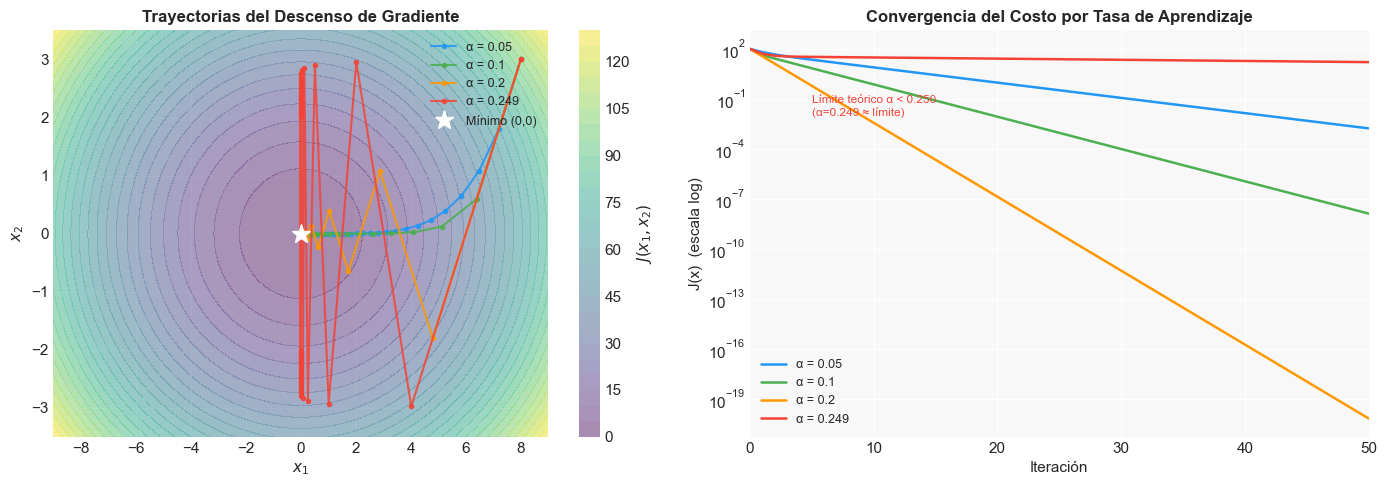

Límite teórico de estabilidad: α < 2/λ_max = 2/8.0 = 0.2500
Con α = 0.249: el método converge muy lentamente (oscila antes de descender).


In [49]:
# ─── 4.3 Visualización: trayectorias y convergencia ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curvas de nivel
x1g = np.linspace(-9, 9, 250)
x2g = np.linspace(-3.5, 3.5, 250)
X1, X2 = np.meshgrid(x1g, x2g)
Z  = X1**2 + 4*X2**2

cs = axes[0].contourf(X1, X2, Z, levels=25, cmap="viridis", alpha=0.45)
axes[0].contour(X1, X2, Z, levels=25, colors="white", linewidths=0.3, alpha=0.4)
plt.colorbar(cs, ax=axes[0], label="$J(x_1, x_2)$")

for alpha, col in zip(alphas, colores):
    h = resultados[alpha]["x"]
    axes[0].plot(h[:,0], h[:,1], "o-", color=col, ms=3, alpha=0.85, lw=1.5,
                 label=f"α = {alpha}")

axes[0].plot(0, 0, "w*", ms=14, zorder=10, label="Mínimo (0,0)")
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
axes[0].set_title("Trayectorias del Descenso de Gradiente")
axes[0].legend(fontsize=9, loc="upper right")

# Costo vs iteración (escala log)
for alpha, col in zip(alphas, colores):
    Jh = resultados[alpha]["J"]
    axes[1].semilogy(Jh, color=col, lw=1.8, label=f"α = {alpha}")

axes[1].set_xlabel("Iteración")
axes[1].set_ylabel("J(x)  (escala log)")
axes[1].set_title("Convergencia del Costo por Tasa de Aprendizaje")
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, n_iter)

# Anotación del límite de estabilidad
axes[1].axvline(0, ls="none")
lambda_max = 8.0
alpha_lim  = 2.0 / lambda_max
axes[1].annotate(f"Límite teórico α < {alpha_lim:.3f}\n(α=0.249 ≈ límite)",
                 xy=(5, 1e-2), fontsize=8.5, color="#F44336")

plt.tight_layout()
plt.savefig("m4_gradient.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"Límite teórico de estabilidad: α < 2/λ_max = 2/{lambda_max} = {alpha_lim:.4f}")
print(f"Con α = 0.249: el método converge muy lentamente (oscila antes de descender).")


In [50]:
# ─── 4.4 Optimización del cilindro (problema de ingeniería) ────────────────
# Minimizar J(r,h) = 2πr² + 2πrh  sujeto implícitamente a volumen fijo
# (problema libre para demostrar el algoritmo)

x_cil  = np.array([r0, h0])     # [r, h] = [2, 5]  punto inicial del taller
alpha  = 0.001                   # tasa de aprendizaje (ajustada para esta escala)
n_iter_cil = 200
hist_cil_x = [x_cil.copy()]
hist_cil_J = [J_cilindro(*x_cil)]

print(f"Optimización del cilindro cerrado:")
print(f"  Punto inicial: r={x_cil[0]}, h={x_cil[1]},  J = {J_cilindro(*x_cil):.2f}")
print()
print(f"{'Iter':>5} | {'r':>8} | {'h':>8} | {'J(r,h)':>10} | {'‖∇J‖':>10}")
print("─" * 50)

for i in range(n_iter_cil):
    g    = grad_J_cilindro(*x_cil)
    x_cil = x_cil - alpha * g
    hist_cil_x.append(x_cil.copy())
    hist_cil_J.append(J_cilindro(*x_cil))
    if i in [0, 1, 2, 9, 49, 199]:
        print(f"{i+1:>5} | {x_cil[0]:>8.4f} | {x_cil[1]:>8.4f} | {J_cilindro(*x_cil):>10.4f} | {np.linalg.norm(g):>10.4f}")

hist_cil_x = np.array(hist_cil_x)

print()
print("Nota: el mínimo irrestricto de 2πr² + 2πrh es (r→0, h→0).")
print("En un problema real se añadiría la restricción de volumen V = πr²h = cte,")
print("lo que conduce al cilindro óptimo con h = 2r (forma de lata estándar).")


Optimización del cilindro cerrado:
  Punto inicial: r=2.0, h=5.0,  J = 87.96

 Iter |        r |        h |     J(r,h) |       ‖∇J‖
──────────────────────────────────────────────────
    1 |   1.9435 |   4.9874 |    84.6335 |    57.9281
    2 |   1.8877 |   4.9752 |    81.3991 |    57.0805
    3 |   1.8327 |   4.9634 |    78.2585 |    56.2464
   10 |   1.4686 |   4.8897 |    58.6727 |    50.7696
   50 |  -0.0614 |   4.7251 |    -1.7988 |    29.2846
  200 |  -2.3170 |   6.0559 |   -54.4305 |    17.0441

Nota: el mínimo irrestricto de 2πr² + 2πrh es (r→0, h→0).
En un problema real se añadiría la restricción de volumen V = πr²h = cte,
lo que conduce al cilindro óptimo con h = 2r (forma de lata estándar).


### 📝 Ejercicio 4

Para la función $J(x_1, x_2) = (x_1 - 3)^2 + 2(x_2 + 1)^2$:

1. Calcule el gradiente $\nabla J$ analíticamente.
2. Determine el mínimo exacto y verifique que $H$ es definida positiva.
3. Implemente el descenso de gradiente con $\alpha = 0.1$ y $x_0 = (0, 0)$.
4. ¿Cuántas iteraciones necesita para que $\|\nabla J\| < 10^{-6}$?

```python
# ─── Ejercicio 4: Descenso de Gradiente para J(x₁,x₂) = (x₁-3)²+2(x₂+1)² ──

# 1. Gradiente analítico
# J(x₁,x₂) = (x₁-3)² + 2(x₂+1)²
# ∂J/∂x₁   = 2(x₁-3)
# ∂J/∂x₂   = 4(x₂+1)
# ∇J        = [2(x₁-3), 4(x₂+1)]

def J4(x: np.ndarray) -> float:
    return float((x[0]-3)**2 + 2*(x[1]+1)**2)

def grad_J4(x: np.ndarray) -> np.ndarray:
    """∇J = [2(x₁-3), 4(x₂+1)]"""
    return np.array([2.0*(x[0]-3), 4.0*(x[1]+1)])

print("1. Gradiente analítico:")
print("   ∂J/∂x₁ = 2(x₁ − 3)")
print("   ∂J/∂x₂ = 4(x₂ + 1)")
print()

# 2. Mínimo exacto y condición de segundo orden
x_star = np.array([3.0, -1.0])
print(f"2. Mínimo exacto: x* = {x_star}  →  J(x*) = {J4(x_star)}")
print(f"   Verificación: ∇J(x*) = {grad_J4(x_star)}  (debe ser [0, 0])")
print()
# Hessiana H = diag(2, 4)
H = np.diag([2.0, 4.0])
evals = np.linalg.eigvalsh(H)
print(f"   Hessiana H = diag(2, 4)  →  eigenvalores: {evals}")
print(f"   H es definida positiva: {np.all(evals > 0)} → x* es MÍNIMO GLOBAL")
lambda_max = evals.max()
alpha_lim  = 2.0 / lambda_max
print(f"   Límite de estabilidad: α < 2/λ_max = 2/{lambda_max} = {alpha_lim:.4f}")
print()

# 3. Descenso de gradiente con α=0.1, x₀=(0,0)
alpha   = 0.1
x0      = np.array([0.0, 0.0])
x       = x0.copy()
hist_x  = [x.copy()]
hist_J  = [J4(x)]
hist_ng = [np.linalg.norm(grad_J4(x))]

print(f"3. Descenso de Gradiente  α=0.1,  x₀=(0, 0)")
print(f"{'Iter':>5} | {'x₁':>9} | {'x₂':>9} | {'J(x)':>12} | {'‖∇J‖':>12}")
print("─"*55)
print(f"{'0':>5} | {x[0]:>9.4f} | {x[1]:>9.4f} | {J4(x):>12.6f} | {hist_ng[0]:>12.6f}")

n_conv = None
for i in range(500):
    g_val  = grad_J4(x)
    x      = x - alpha * g_val
    norm_g = np.linalg.norm(grad_J4(x))
    hist_x.append(x.copy())
    hist_J.append(J4(x))
    hist_ng.append(norm_g)
    if i+1 in [1, 2, 4, 9, 19, 49, 69] or norm_g < 1e-6:
        print(f"{i+1:>5} | {x[0]:>9.4f} | {x[1]:>9.4f} | {J4(x):>12.6f} | {norm_g:>12.6f}")
    if norm_g < 1e-6 and n_conv is None:
        n_conv = i + 1
        break

hist_x  = np.array(hist_x)
hist_J  = np.array(hist_J)
hist_ng = np.array(hist_ng)

print()
print(f"4. Iteraciones para ‖∇J‖ < 10⁻⁶: {n_conv}")
print(f"   Punto final: x₁={x[0]:.8f},  x₂={x[1]:.8f}")
print(f"   J(x_final)  = {J4(x):.2e}  ≈ 0  ✓")

# ── Visualización ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curvas de nivel y trayectoria
x1g = np.linspace(-0.5, 4.5, 250)
x2g = np.linspace(-2.5, 1.5, 250)
X1, X2 = np.meshgrid(x1g, x2g)
Z = (X1-3)**2 + 2*(X2+1)**2

cs = axes[0].contourf(X1, X2, Z, levels=20, cmap="viridis", alpha=0.5)
axes[0].contour(X1, X2, Z, levels=20, colors="white", linewidths=0.3, alpha=0.4)
plt.colorbar(cs, ax=axes[0], label="$J(x_1, x_2)$")
axes[0].plot(hist_x[:,0], hist_x[:,1], "o-", color="#FF5722", ms=3,
             alpha=0.85, lw=1.5, label=f"Trayectoria (α=0.1)")
axes[0].plot(x0[0], x0[1], "gs", ms=10, zorder=10, label="Inicio (0,0)")
axes[0].plot(3, -1, "w*", ms=14, zorder=10, label="Mínimo (3,−1)")
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
axes[0].set_title("Trayectoria del Descenso de Gradiente")
axes[0].legend(fontsize=9)

# Costo y norma del gradiente vs iteraciones
iters = np.arange(len(hist_J))
axes[1].semilogy(iters, hist_J,  "b-",  lw=1.8, label="$J(x)$")
axes[1].semilogy(iters, hist_ng, "r--", lw=1.8, label="$\|\nabla J\|$")
axes[1].axhline(1e-6, color="g", ls=":", lw=1.2, label="Tolerancia $10^{-6}$")
if n_conv:
    axes[1].axvline(n_conv, color="orange", ls="--", lw=1.2,
                    label=f"Convergencia iter {n_conv}")
axes[1].set_xlabel("Iteración")
axes[1].set_ylabel("Valor (escala log)")
axes[1].set_title(f"Convergencia  |  {n_conv} iteraciones para ‖∇J‖ < 10⁻⁶")
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, len(hist_J)-1)

plt.suptitle("Ejercicio 4 — Descenso de Gradiente: $J(x_1,x_2)=(x_1-3)^2+2(x_2+1)^2$",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("e4_gradient_J.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"\nResumen final:")
print(f"  Mínimo exacto  : x* = (3, -1),  J(x*) = 0")
print(f"  Resultado GD   : x  = ({x[0]:.6f}, {x[1]:.6f}),  J = {J4(x):.2e}")
print(f"  Iteraciones    : {n_conv}")
print(f"  Límite α       : α < {alpha_lim:.4f} → α=0.1 es estable ✓")
```


---
## Resumen y Conexiones

| Módulo | Función NumPy clave | Orden de complejidad |
|--------|---------------------|----------------------|
| PCA / SVD | `np.linalg.svd` | $\mathcal{O}(n p^2)$ para $n \gg p$ |
| Regresión | `np.linalg.solve` | $\mathcal{O}(p^3)$ |
| Newton-Raphson | — manual — | $\mathcal{O}(k)$, $k$ iteraciones |
| Descenso de Gradiente | — manual — | $\mathcal{O}(k \cdot p)$, $k$ iteraciones |

### Conexión entre módulos

```
Datos brutos (X)
        │
        ▼  Módulo 1 (SVD/PCA)
 X_reducida (menos dimensiones)
        │
        ▼  Módulo 2 (Ecuación Normal)
  Modelo β (parámetros ajustados)
        │
        ▼  Módulo 4 (Descenso de Gradiente)
  Optimización iterativa del modelo
        │
        ▼  Módulo 3 (Newton-Raphson)
  Raíces → inversión del modelo, umbrales
```

**Para profundizar:**  
- SVD truncada eficiente: `scipy.sparse.linalg.svds`  
- Regresión robusta: `sklearn.linear_model.HuberRegressor`  
- Optimización con restricciones: `scipy.optimize.minimize` con `constraints`
